# 7-4 Multi-asset Strategies

[![在 Colab 開啟](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/finlab-python/hahow-crypto-course/blob/main/7-4_multi_asset_strategies.ipynb)

**對應影片**：第 7 章 單元 7-4【多商品單策略研發】Multi-asset Strategies

**和影片的差異**

- 資料改從 Binance 公開資料端點下載（`data-api.binance.vision`，不需金鑰、Colab 可用），`get_all_binance` 的寫法和影片一樣。
- vectorbt 改版：`cumulative_returns()`、`final_value()`、`daily_returns()`、`drawdown()` 都是要加括號的函式；影片寫法不同時，以本筆記本為準。
- VETBTC 已於 2026 年 3 月下架，改用 BNBBTC。
- 影片用 `start_bar=2000` 略過每個幣種的前 2000 根 K 線；現在資料多很多，改成只用 `START` 之後的資料做最佳化（資料量和影片相近，Colab 免費版幾分鐘內跑完），最終策略仍用完整歷史。
- 合成 K 線的時間間隔改成 4h（影片誤設為 1h），日報酬與過擬合分析才正確。

In [1]:
%pip install -q finlab_crypto==0.3.0

Note: you may need to restart the kernel to use updated packages.


In [2]:
# QUICK_RUN = True 會縮小最佳化範圍，幾十秒就跑完（自動測試使用）。上課請維持 False。
QUICK_RUN = False

In [3]:
# 最佳化使用的資料起點；改成 None 使用全部歷史（需要較多記憶體與時間）
START = '2022-01-01'

In [4]:
import finlab_crypto

finlab_crypto.setup()

# 下載歷史資料

In [5]:
symbols = ['XRPBTC', 'ADABTC', 'LINKUSDT', 'ETHBTC', 'BNBBTC']
ohlcvs = {s: finlab_crypto.crawler.get_all_binance(s, '4h') for s in symbols}

XRPBTC 4h: 19475 candles (2017-11-02 ~ 2026-09-24 12:00 UTC)


ADABTC 4h: 19305 candles (2017-11-30 ~ 2026-09-24 12:00 UTC)


LINKUSDT 4h: 16845 candles (2019-01-16 ~ 2026-09-24 12:00 UTC)


ETHBTC 4h: 20141 candles (2017-07-14 ~ 2026-09-24 12:00 UTC)


BNBBTC 4h: 20141 candles (2017-07-14 ~ 2026-09-24 12:00 UTC)


# 把多個幣種接成一條 K 線

In [6]:
import numpy as np
import pandas as pd


def concat_assets(ohlcvs, symbols, freq='4h'):
    """把多個幣種的 K 線首尾相接成一條「合成」K 線，讓一組參數同時在所有幣種上回測。"""
    returns = pd.Series(np.concatenate([ohlcvs[s].close.pct_change().values for s in symbols]))
    close = (returns.fillna(0) + 1).cumprod()

    def scaled(column):
        # 開高低相對於收盤價的比例不變，換算到合成的收盤價上
        return np.concatenate([(ohlcvs[s][column] / ohlcvs[s].close).values for s in symbols]) * close.values

    return pd.DataFrame({
        'open': scaled('open'),
        'high': scaled('high'),
        'low': scaled('low'),
        'close': close.values,
        'volume': np.concatenate([ohlcvs[s].volume.values for s in symbols]),
    }, index=pd.date_range('2000-01-01', periods=len(close), freq=freq)).dropna()

<Axes: >

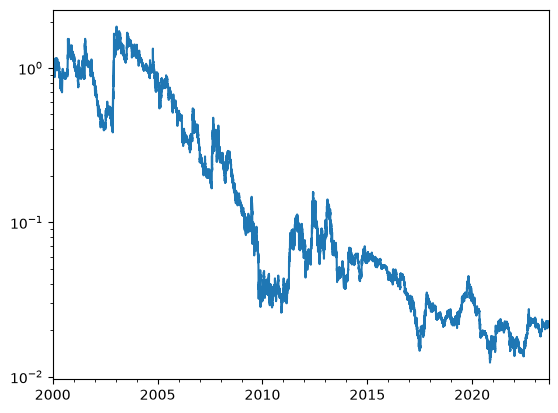

In [7]:
ohlcv_comb = concat_assets({s: ohlcv.loc[START:] for s, ohlcv in ohlcvs.items()}, symbols)
ohlcv_comb.close.plot(logy=True)

# 均線策略

最佳化要回測 2 × 14 × 14 = 392 組參數，Colab 免費版約 1 分鐘；
趕時間可以先把上方的 `QUICK_RUN` 改成 `True`。

In [8]:
from finlab_crypto import Strategy
from finlab_crypto.indicators import trends


@Strategy(name='sma', n1=20, n2=40)
def trend_strategy(ohlcv):
    fast = trends[trend_strategy.name](ohlcv.close, trend_strategy.n1)
    slow = trends[trend_strategy.name](ohlcv.close, trend_strategy.n2)

    entries = (fast > slow) & (fast.shift() < slow.shift())
    exits = (fast < slow) & (fast.shift() > slow.shift())

    figures = {
        'overlaps': {
            'trend1': fast,
            'trend2': slow,
        }
    }
    return entries, exits, figures


trends.keys()

dict_keys(['sma', 'wma', 'lowpass', 'hullma', 'zlma', 'alma', 'detrend', 'linear_reg'])

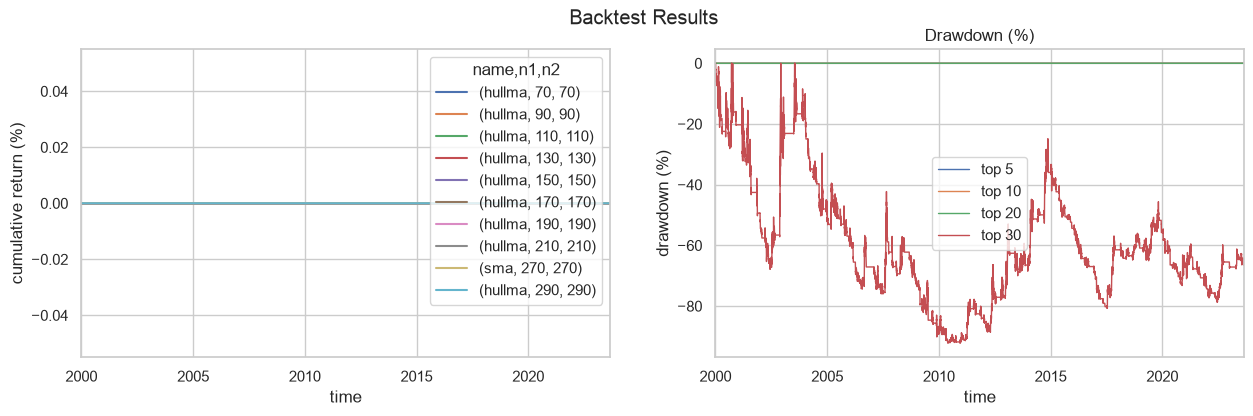

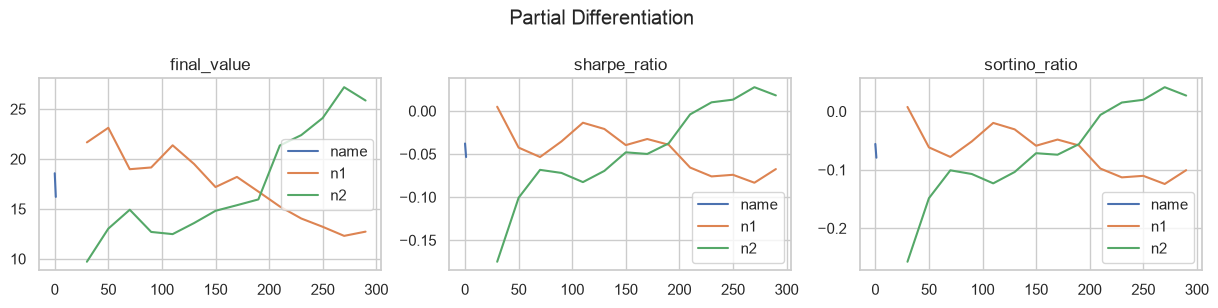

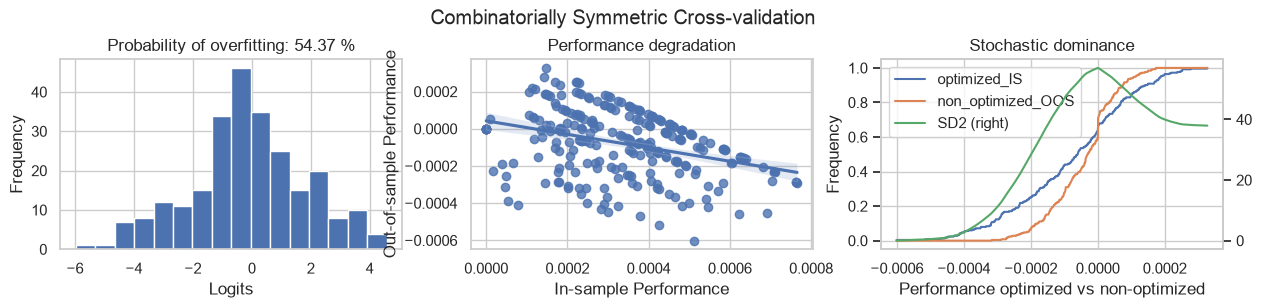

In [9]:
step = 90 if QUICK_RUN else 20
portfolio = trend_strategy.backtest(ohlcv_comb, variables={
    'name': ['sma', 'hullma'],
    'n1': np.arange(30, 300, step),
    'n2': np.arange(30, 300, step),
}, freq='4h', plot=True)

In [10]:
# inf 是無限大，先換成空值再排序
portfolio.sharpe_ratio().replace([np.inf, -np.inf], np.nan).dropna().nlargest(20)

name    n1   n2 
hullma  50   270    0.194467
             290    0.171516
             250    0.148872
sma     110  210    0.145636
hullma  30   250    0.134025
             290    0.120425
        70   230    0.109296
sma     170  50     0.108564
hullma  30   270    0.107121
             230    0.099136
sma     170  210    0.098351
hullma  210  290    0.098237
        70   270    0.097898
        50   230    0.095632
        230  250    0.091117
sma     150  70     0.090669
hullma  70   250    0.087471
sma     90   270    0.086838
hullma  70   290    0.086686
sma     130  230    0.084898
Name: sharpe_ratio, dtype: float64

## 最終策略：每個幣種分別回測（完整歷史），再等權重組合

In [11]:
import matplotlib.pyplot as plt


def plot_equal_weight(strategy, variables):
    """每個幣種分別回測，再等權重組合成一個投資組合。"""
    equity = pd.DataFrame({
        symbol: strategy.backtest(ohlcv, variables, freq='4h').cumulative_returns()
        for symbol, ohlcv in ohlcvs.items()
    })
    (equity + 1).plot(logy=True, title='Cumulative return by symbol')
    plt.show()

    daily = (equity + 1).pct_change().fillna(0)
    (daily.mean(axis=1) + 1).cumprod().plot(title='Equal-weight portfolio')
    plt.show()

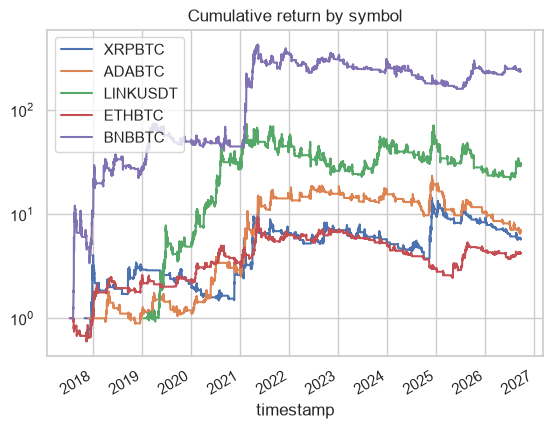

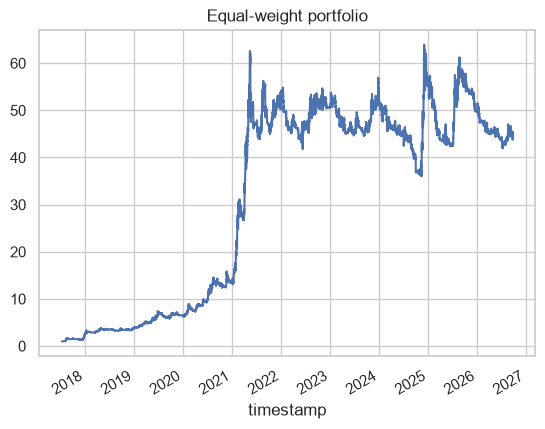

In [12]:
plot_equal_weight(trend_strategy, dict(name='sma', n1=30, n2=130))

# 突破策略

收盤價創 N 根 K 線新高時買進，創新低時賣出。最佳化要回測 19 × 19 = 361 組參數，Colab 免費版約 1 分鐘。

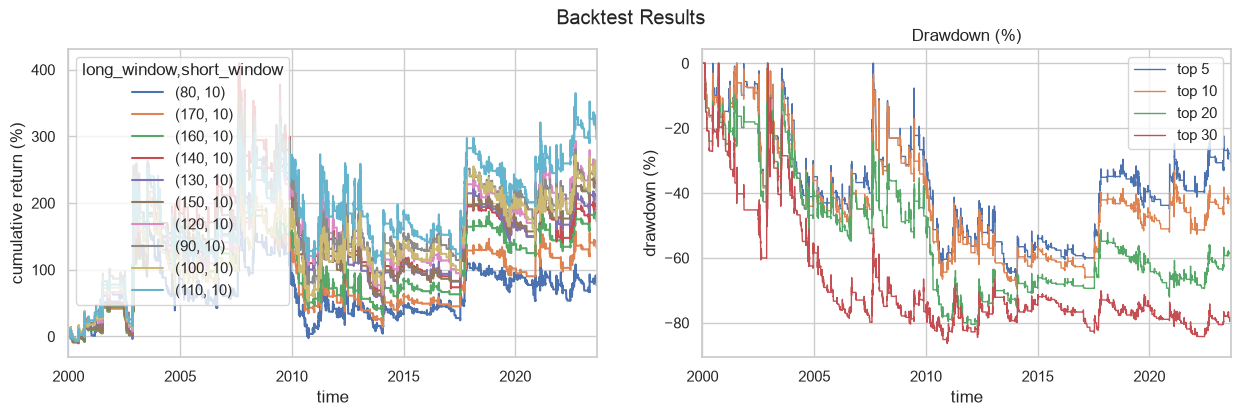

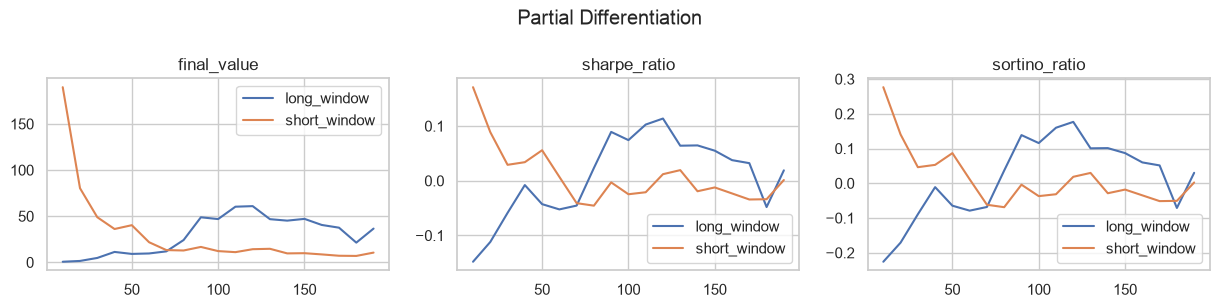

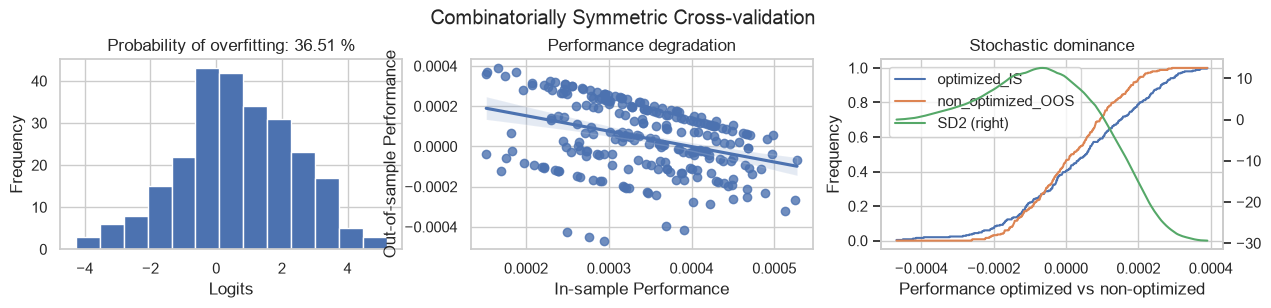

In [13]:
@Strategy(long_window=30, short_window=30)
def breakout_strategy(ohlcv):
    ub = ohlcv.close.rolling(breakout_strategy.long_window).max()
    lb = ohlcv.close.rolling(breakout_strategy.short_window).min()

    entries = ohlcv.close == ub
    exits = ohlcv.close == lb

    figures = {
        'overlaps': {
            'ub': ub,
            'lb': lb,
        }
    }
    return entries, exits, figures


step = 60 if QUICK_RUN else 10
portfolio = breakout_strategy.backtest(ohlcv_comb, variables={
    'long_window': np.arange(10, 200, step),
    'short_window': np.arange(10, 200, step),
}, freq='4h', plot=True)

## 最終突破策略

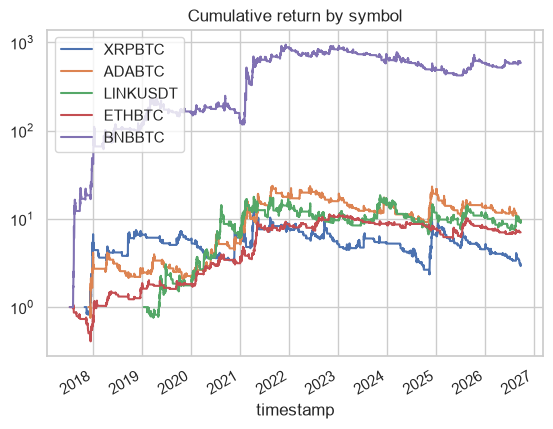

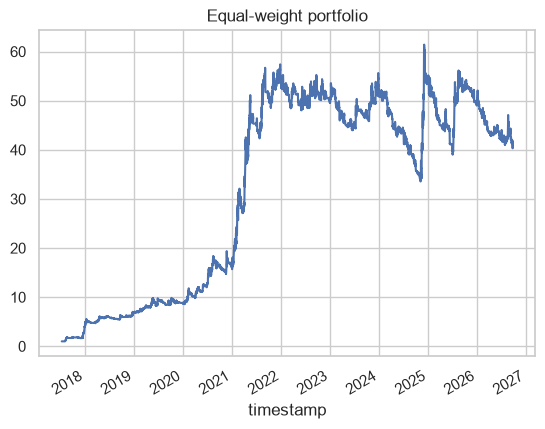

In [14]:
plot_equal_weight(breakout_strategy, dict(long_window=70, short_window=40))

# RSI 策略

RSI > 52 進場、< 50 出場（兩個門檻不同，避免在 50 附近來回進出）。

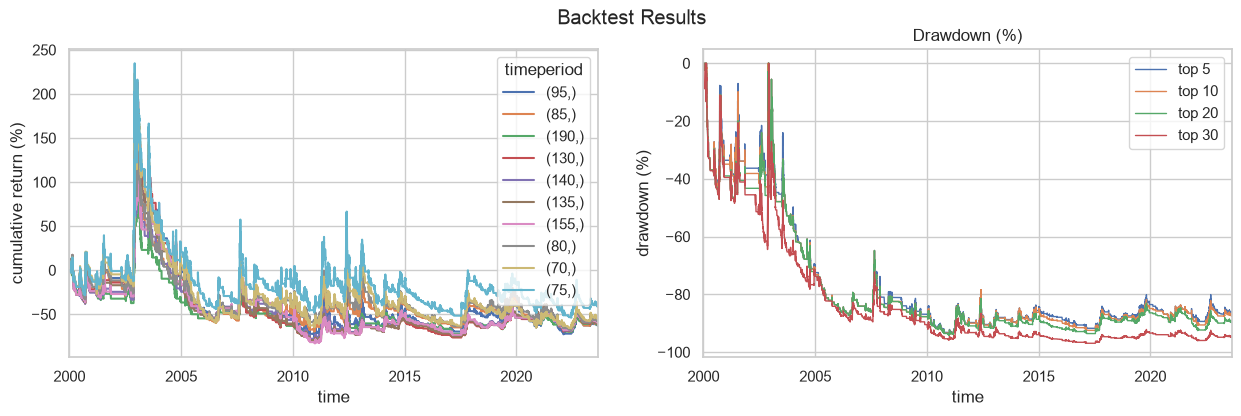

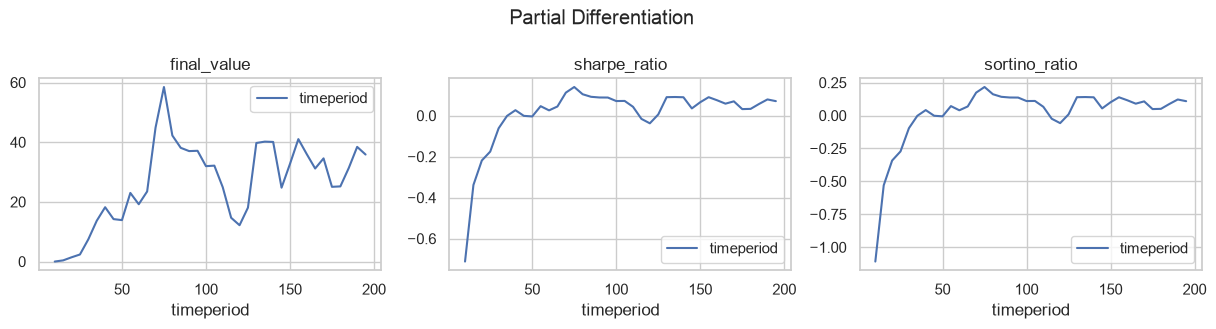

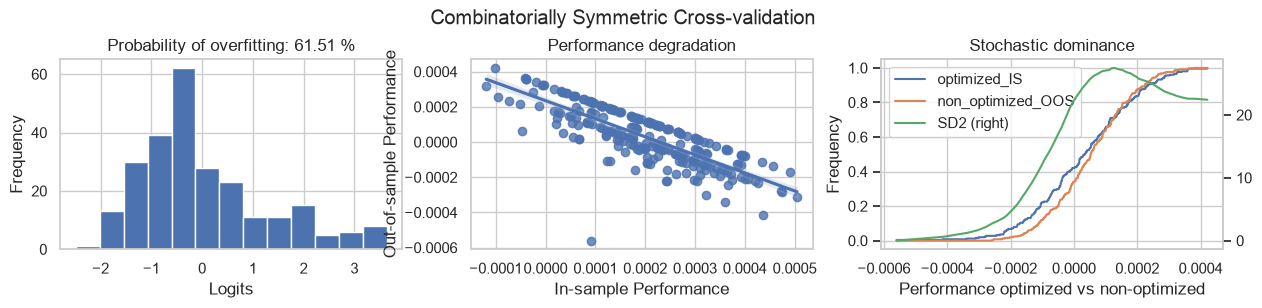

In [15]:
import talib


@Strategy(timeperiod=14)
def rsi_strategy(ohlcv):
    rsi = talib.RSI(ohlcv.close, timeperiod=rsi_strategy.timeperiod)

    entries = rsi > 52
    exits = rsi < 50

    figures = {
        'figures': {
            f'{rsi_strategy.timeperiod}_rsi': rsi
        }
    }
    return entries, exits, figures


step = 60 if QUICK_RUN else 5
portfolio = rsi_strategy.backtest(ohlcv_comb, variables={'timeperiod': np.arange(10, 200, step)},
                                  freq='4h', plot=True)

## 最終 RSI 策略

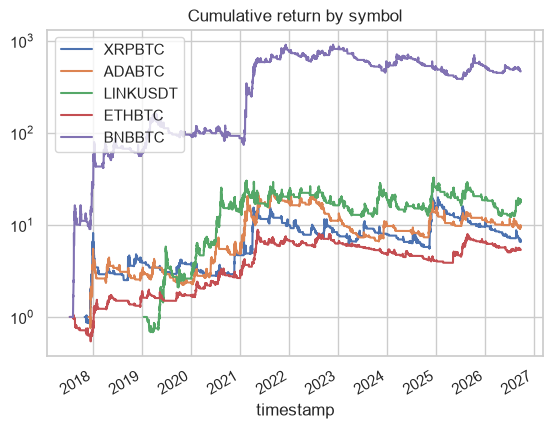

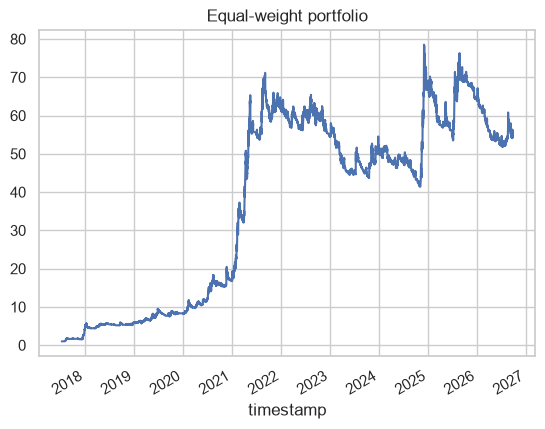

In [16]:
plot_equal_weight(rsi_strategy, dict(timeperiod=60))